# Анализ AutoML baselines (AutoGluon / LightAutoML / H2O)

**Источник:** `tasks/jailbreak_detection/results/metrics.json` — строки `*_automl_baseline` (27 прогонов).

**Сетка:**
- AutoGluon, LightAutoML: few-shot 10/20/50 × seeds 42/123/456 + full × 3 seeds
- H2O: full × 3 seeds (TF-IDF+SVD → табличный AutoML)

**Eval:** WildJailbreak binary, n=2210 (jailbreak=1: 2000, safe=0: 210).


## 1. Загрузка и проверка


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "results" / "metrics.json").is_file():
    TASK_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / "results" / "metrics.json").is_file():
    TASK_ROOT = NOTEBOOK_DIR.parent
else:
    TASK_ROOT = Path("tasks/jailbreak_detection")

METRICS_PATH = TASK_ROOT / "results" / "metrics.json"
assert METRICS_PATH.is_file(), METRICS_PATH

FW_COLORS = {
    "autogluon": "#6c5ce7",
    "lightautoml": "#00b894",
    "h2o": "#e17055",
}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)


def flatten_automl_row(row: dict) -> dict:
    ex = row.get("extra") or {}
    ec = ex.get("eval_counts") or {}
    ss = ex.get("scores_eval_summary") or {}
    mn = row.get("model_name", "")
    fw = mn.replace("_automl_baseline", "") if mn.endswith("_automl_baseline") else mn
    return {
        "framework": fw,
        "model_name": mn,
        "preset": ex.get("preset"),
        "embedder": ex.get("embedder"),
        "mode": row.get("mode"),
        "n_shots": row.get("n_shots"),
        "seed": row.get("seed"),
        "f1": row.get("f1"),
        "precision": row.get("precision"),
        "recall": row.get("recall"),
        "over_refusal_rate": row.get("over_refusal_rate"),
        "tp": ec.get("tp"),
        "fp": ec.get("fp"),
        "fn": ec.get("fn"),
        "tn": ec.get("tn"),
        "n_eval": ec.get("n_eval"),
        "margin_mean": ss.get("margin_mean") if ss else np.nan,
        "score_jb_mean": ss.get("score_col1_mean") if ss else np.nan,
    }


rows = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
automl_rows = [r for r in rows if str(r.get("model_name", "")).endswith("_automl_baseline")]
assert len(automl_rows) == 27, f"expected 27 automl rows, got {len(automl_rows)}"

df = pd.DataFrame([flatten_automl_row(r) for r in automl_rows])
df["shots_label"] = df.apply(
    lambda r: "full" if r["mode"] == "full" else str(int(r["n_shots"])), axis=1
)

# sanity
assert (df["n_eval"] == 2210).all()
assert (df.groupby(["framework", "mode", "n_shots", "seed"]).size() == 1).all()
bad = df[(df["f1"] == 0) & (df["tp"] == 0)]
if len(bad):
    print("WARN: suspicious zero-F1 rows:", bad[["framework", "mode", "n_shots", "seed"]].to_dict("records"))

print(f"Loaded {len(df)} runs from {METRICS_PATH}")
print("Frameworks:", sorted(df["framework"].unique()))
df.groupby("framework").size().rename("n_runs")


Loaded 27 runs from /Users/oleguzov/Desktop/lab_mipt/jailbreak_detection_analysis/tasks/jailbreak_detection/results/metrics.json
Frameworks: ['autogluon', 'h2o', 'lightautoml']


framework
autogluon      12
h2o             3
lightautoml    12
Name: n_runs, dtype: int64

## 2. Сводная таблица (все прогоны)


In [2]:
cols = [
    "framework", "mode", "n_shots", "seed", "f1", "precision", "recall",
    "over_refusal_rate", "tp", "fp", "fn", "tn", "embedder",
]
summary = df[cols].sort_values(["framework", "mode", "n_shots", "seed"])
summary.style.format(
    {
        "f1": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "over_refusal_rate": "{:.4f}",
    },
    precision=0,
).background_gradient(subset=["f1", "recall"], cmap="YlGn")


,framework,mode,n_shots,seed,f1,precision,recall,over_refusal_rate,tp,fp,fn,tn,embedder
0,autogluon,10shot,10,42,0.5102,0.8553,0.3635,0.5857,727,123,1273,87,autogluon_text_default_gpu2
1,autogluon,10shot,10,123,0.6718,0.8781,0.5440,0.7190,1088,151,912,59,autogluon_text_default_gpu2
2,autogluon,10shot,10,456,0.7259,0.8909,0.6125,0.7143,1225,150,775,60,autogluon_text_default_gpu2
3,autogluon,20shot,20,42,0.4799,0.8722,0.3310,0.4619,662,97,1338,113,autogluon_text_default_gpu2
4,autogluon,20shot,20,123,0.7260,0.8879,0.6140,0.7381,1228,155,772,55,autogluon_text_default_gpu2
5,autogluon,20shot,20,456,0.6072,0.8835,0.4625,0.5810,925,122,1075,88,autogluon_text_default_gpu2
6,autogluon,50shot,50,42,0.6434,0.8941,0.5025,0.5667,1005,119,995,91,autogluon_text_default_gpu2
7,autogluon,50shot,50,123,0.7379,0.8864,0.6320,0.7714,1264,162,736,48,autogluon_text_default_gpu2
8,autogluon,50shot,50,456,0.6504,0.9039,0.5080,0.5143,1016,108,984,102,autogluon_text_default_gpu2
9,autogluon,full,nan,42,0.8240,0.9509,0.7270,0.3571,1454,75,546,135,autogluon_text_default_gpu2


## 3. Агрегаты по framework × режим


In [3]:
agg = (
    df.groupby(["framework", "mode", "shots_label"], as_index=False)
    .agg(
        n=("seed", "count"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        f1_max=("f1", "max"),
        recall_mean=("recall", "mean"),
        orr_mean=("over_refusal_rate", "mean"),
    )
    .sort_values(["framework", "mode", "shots_label"])
)
agg


,framework,mode,shots_label,n,f1_mean,f1_std,f1_max,recall_mean,orr_mean
0,autogluon,10shot,10,3,0.635971,0.112252,0.725926,0.506667,0.673016
1,autogluon,20shot,20,3,0.604340,0.123074,0.725983,0.469167,0.593651
2,autogluon,50shot,50,3,0.677247,0.052634,0.737887,0.547500,0.617460
3,autogluon,full,full,3,0.816469,0.012865,0.824029,0.716667,0.368254
4,h2o,full,full,3,0.821903,0.012627,0.835471,0.743500,0.623810
5,lightautoml,10shot,10,3,0.451499,0.121213,0.572888,0.305833,0.253968
6,lightautoml,20shot,20,3,0.683223,0.028061,0.714976,0.548333,0.528571
7,lightautoml,50shot,50,3,0.685480,0.059192,0.725836,0.550333,0.482540
8,lightautoml,full,full,3,0.821085,0.001458,0.822675,0.734667,0.522222


## 4. Heatmap F1 (framework × shots, mean по seeds)


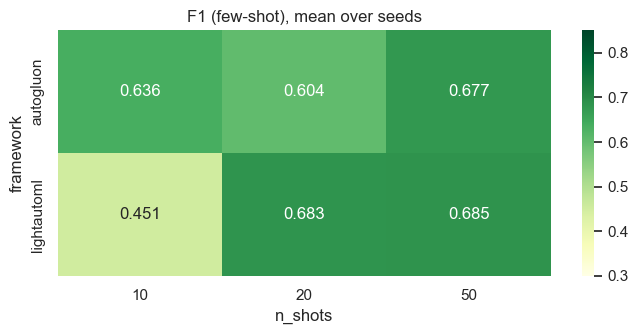

Full train (100k), F1 by framework:


,mean,std,min,max
framework,,,,
autogluon,0.816469,0.012865,0.801615,0.824029
h2o,0.821903,0.012627,0.810494,0.835471
lightautoml,0.821085,0.001458,0.819810,0.822675


In [4]:
few = df[df["mode"] != "full"].copy()
pivot_f1 = few.pivot_table(
    index="framework", columns="shots_label", values="f1", aggfunc="mean"
)
order_cols = [c for c in ["10", "20", "50"] if c in pivot_f1.columns]
pivot_f1 = pivot_f1[order_cols]

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="YlGn", vmin=0.3, vmax=0.85, ax=ax)
ax.set_title("F1 (few-shot), mean over seeds")
ax.set_xlabel("n_shots")
plt.tight_layout()
plt.show()

full = df[df["mode"] == "full"].copy()
full_mean = full.groupby("framework")["f1"].agg(["mean", "std", "min", "max"])
print("Full train (100k), F1 by framework:")
display(full_mean)


## 5. Recall vs Over-refusal (trade-off)


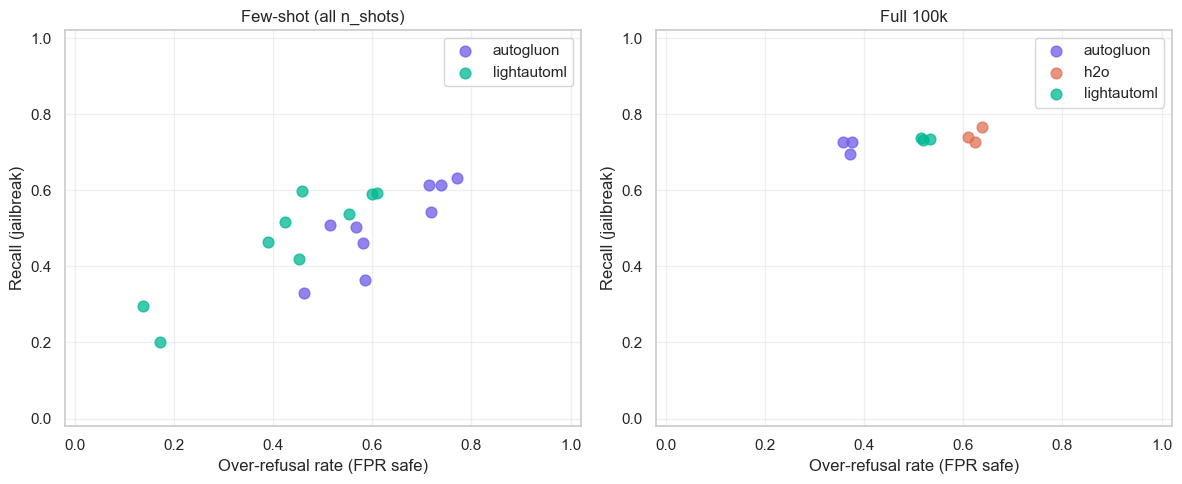

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, subset, title in zip(
    axes,
    [df[df["mode"] != "full"], df[df["mode"] == "full"]],
    ["Few-shot (all n_shots)", "Full 100k"],
):
    for fw, g in subset.groupby("framework"):
        ax.scatter(
            g["over_refusal_rate"],
            g["recall"],
            label=fw,
            color=FW_COLORS.get(fw, "gray"),
            alpha=0.75,
            s=60,
        )
    ax.set_xlabel("Over-refusal rate (FPR safe)")
    ax.set_ylabel("Recall (jailbreak)")
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Стабильность по seed (boxplot F1)


/var/folders/vp/cymn6y2131dgq9c9g00ppp780000gn/T/ipykernel_2542/3353320392.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


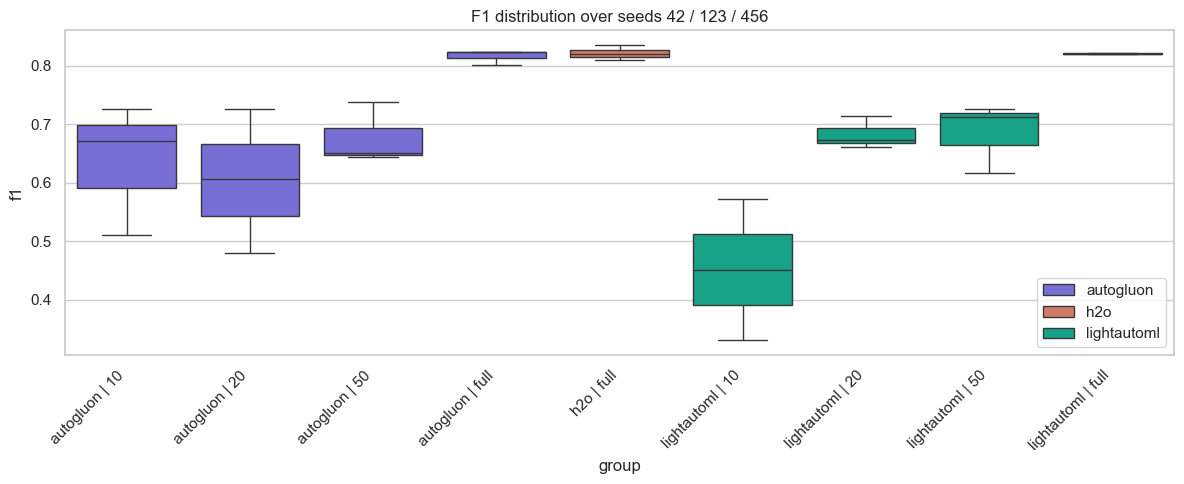

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = df.copy()
plot_df["group"] = plot_df["framework"] + " | " + plot_df["shots_label"]
order = sorted(plot_df["group"].unique(), key=lambda x: (x.split("|")[0], x.split("|")[1]))
sns.boxplot(data=plot_df, x="group", y="f1", hue="framework", palette=FW_COLORS, order=order, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("F1 distribution over seeds 42 / 123 / 456")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 7. Лучшие конфигурации и сравнение с AutoIntent (classic-light)


In [7]:
best = (
    df.sort_values("f1", ascending=False)
    .groupby("framework", as_index=False)
    .first()[["framework", "mode", "n_shots", "seed", "f1", "recall", "over_refusal_rate"]]
)
print("Best F1 per framework:")
display(best)

ai = [r for r in rows if r.get("model_name") == "autointent_classic-light_autoembedder"]
if ai:
    dai = pd.DataFrame(
        {
            "mode": [r["mode"] for r in ai],
            "n_shots": [r.get("n_shots") for r in ai],
            "seed": [r["seed"] for r in ai],
            "f1": [r["f1"] for r in ai],
            "recall": [r["recall"] for r in ai],
            "orr": [r["over_refusal_rate"] for r in ai],
        }
    )
    dai["shots_label"] = dai.apply(
        lambda r: "full" if r["mode"] == "full" else str(int(r["n_shots"])), axis=1
    )
    cmp = (
        df.groupby(["framework", "shots_label"], as_index=False)["f1"].mean()
        .merge(
            dai.groupby("shots_label", as_index=False)["f1"].mean().rename(
                columns={"f1": "f1_classic_light"}
            ),
            on="shots_label",
            how="outer",
        )
        .sort_values(["shots_label", "framework"])
    )
    print("Mean F1: AutoML vs AutoIntent classic-light (same eval, mean over seeds):")
    display(cmp)
else:
    print("No autointent_classic-light rows in metrics.json for comparison.")


Best F1 per framework:


,framework,mode,n_shots,seed,f1,recall,over_refusal_rate
0,autogluon,full,50.0,42,0.824029,0.7270,0.357143
1,h2o,full,NaN,456,0.835471,0.7655,0.638095
2,lightautoml,full,50.0,42,0.822675,0.7365,0.514286


Mean F1: AutoML vs AutoIntent classic-light (same eval, mean over seeds):


,framework,shots_label,f1,f1_classic_light
0,autogluon,10,0.635971,0.756886
1,lightautoml,10,0.451499,0.756886
2,autogluon,20,0.604340,0.796027
3,lightautoml,20,0.683223,0.796027
4,autogluon,50,0.677247,0.730804
5,lightautoml,50,0.685480,0.730804
6,autogluon,full,0.816469,0.907909
7,h2o,full,0.821903,0.907909
8,lightautoml,full,0.821085,0.907909


## 8. Выводы


In [8]:
full_rank = df[df["mode"] == "full"].groupby("framework")["f1"].mean().sort_values(ascending=False)
few_rank = df[df["mode"] != "full"].groupby("framework")["f1"].mean().sort_values(ascending=False)

print("=== AutoML baselines summary ===")
print(f"Runs: {len(df)} | Eval n=2210")
print("\nFull 100k — mean F1:")
for fw, v in full_rank.items():
    print(f"  {fw:12s} {v:.4f}")
print("\nFew-shot — mean F1:")
for fw, v in few_rank.items():
    print(f"  {fw:12s} {v:.4f}")

worst_orr = df.loc[df["over_refusal_rate"].idxmax()]
best_f1 = df.loc[df["f1"].idxmax()]
print(f"\nBest F1 overall: {best_f1['framework']} {best_f1['mode']} seed={best_f1['seed']} "
      f"n_shots={best_f1['n_shots']} → F1={best_f1['f1']:.4f}")
print(f"Highest ORR: {worst_orr['framework']} {worst_orr['mode']} seed={worst_orr['seed']} "
      f"→ ORR={worst_orr['over_refusal_rate']:.4f}")


=== AutoML baselines summary ===
Runs: 27 | Eval n=2210

Full 100k — mean F1:
  h2o          0.8219
  lightautoml  0.8211
  autogluon    0.8165

Few-shot — mean F1:
  autogluon    0.6392
  lightautoml  0.6067

Best F1 overall: h2o full seed=456 n_shots=nan → F1=0.8355
Highest ORR: autogluon 50shot seed=123 → ORR=0.7714
